In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(GenomeInfoDb)
library(jsonlite)
library(EnsDb.Mmusculus.v79)
library(stringr)
library(copent)
library(ComplexHeatmap)
library(circlize)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aper

In [2]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig2')

#### Figure 2b: Estimate per-tissue, per-histone entropy

In [3]:
merged_obj <- readRDS('processed_data/aging_brain_merged_registered_tiled.rds')

In [4]:
entropy_df <- data.frame(annotation=character(),
                         age=character(),
                         assay=character(),
                         entropy=numeric())

annotations <- c('fiber tracts', 'hippocampus', 'isocortex', 'striatum', 'thalamus', 'hypothalamus')
assays <- c('h3k9me3_Spatial_Tile', 'h3k4me3_Spatial_Tile', 'h3k27me3_Spatial_Tile', 'h3k4me1_Spatial_Tile', 'h3k27ac_Spatial_Tile')
age_groups <- c('3m', '12m', '18m', '24m')


In [5]:
for(annotation in annotations){
  subset_obj <- subset(merged_obj, subset = annotation_assigned == annotation)

  for (assay in assays){
    DefaultAssay(subset_obj) <- assay

      Key(subset_obj@assays[[assay]]) <- paste0(gsub('_', '', Key(subset_obj@assays[[assay]])), '_', collapse='')

      subset_obj <- RunTFIDF(subset_obj)
      subset_obj <- FindTopFeatures(subset_obj, min.cutoff = 'q0')
      subset_obj <- RunSVD(subset_obj)

      lsi_embeddings <- Embeddings(subset_obj, 'lsi')[,2:50]
      for (age in age_groups){

        age_embeddings <- lsi_embeddings[grepl(age, rownames(lsi_embeddings)) , ]
        if (length(age_embeddings) > 0){
          entropy <- entknn(age_embeddings, k=30, dt=1)

          entropy_df <- rbind(entropy_df, data.frame(annotation=annotation,
                                                    age=age,
                                                    assay=assay,
                                                    entropy=entropy))
        } else { 
          entropy_df <- rbind(entropy_df, data.frame(annotation=annotation,
                                                    age=age,
                                                    assay=assay,
                                                    entropy=NA))
        }
      }
  }

  # Compute this for gene expression also
  DefaultAssay(subset_obj) <- 'RNA_Spatial'
  subset_obj <- NormalizeData(subset_obj)
  subset_obj <- FindVariableFeatures(subset_obj, selection.method = 'vst', nfeatures = 2000)
  subset_obj <- ScaleData(subset_obj, features = VariableFeatures(object = subset_obj))
  subset_obj <- RunPCA(subset_obj, features = VariableFeatures(object = subset_obj), npcs = 50)
  pca_embeddings <- Embeddings(subset_obj, 'pca')
  for (age in age_groups){
    age_embeddings <- pca_embeddings[grepl(age, rownames(pca_embeddings)) , ]

    if (length(age_embeddings > 0)){
      entropy <- entknn(age_embeddings, k=30, dt=1)
      entropy_df <- rbind(entropy_df, data.frame(annotation=annotation,
                                                age=age,
                                                assay='RNA_Spatial',
                                                entropy=entropy))
    } else {
      entropy_df <- rbind(entropy_df, data.frame(annotation=annotation,
                                                age=age,
                                                assay='RNA_Spatial',
                                                entropy=NA))
    }
  }
}

entropy_df$age <- factor(entropy_df$age, levels=c('3m', '12m', '18m', '24m'))


Warning message:
"Removing 216 cells missing data for vars requested"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "cou

In [6]:
entropy_df[['differential_entropy']] <- 0
for (assay_test in unique(entropy_df$assay)){
  for (annotation_test in annotations){
    entropy_df[entropy_df$assay == assay_test & entropy_df$annotation == annotation_test, 'differential_entropy'] <-
      entropy_df[entropy_df$assay == assay_test & entropy_df$annotation == annotation_test , 'entropy'] -
      entropy_df[entropy_df$assay == assay_test & entropy_df$annotation == annotation_test & entropy_df$age == '3m', 'entropy']
  }
}

Warning message:
"Removed 6 rows containing missing values or values outside the scale range (`geom_point()`)."


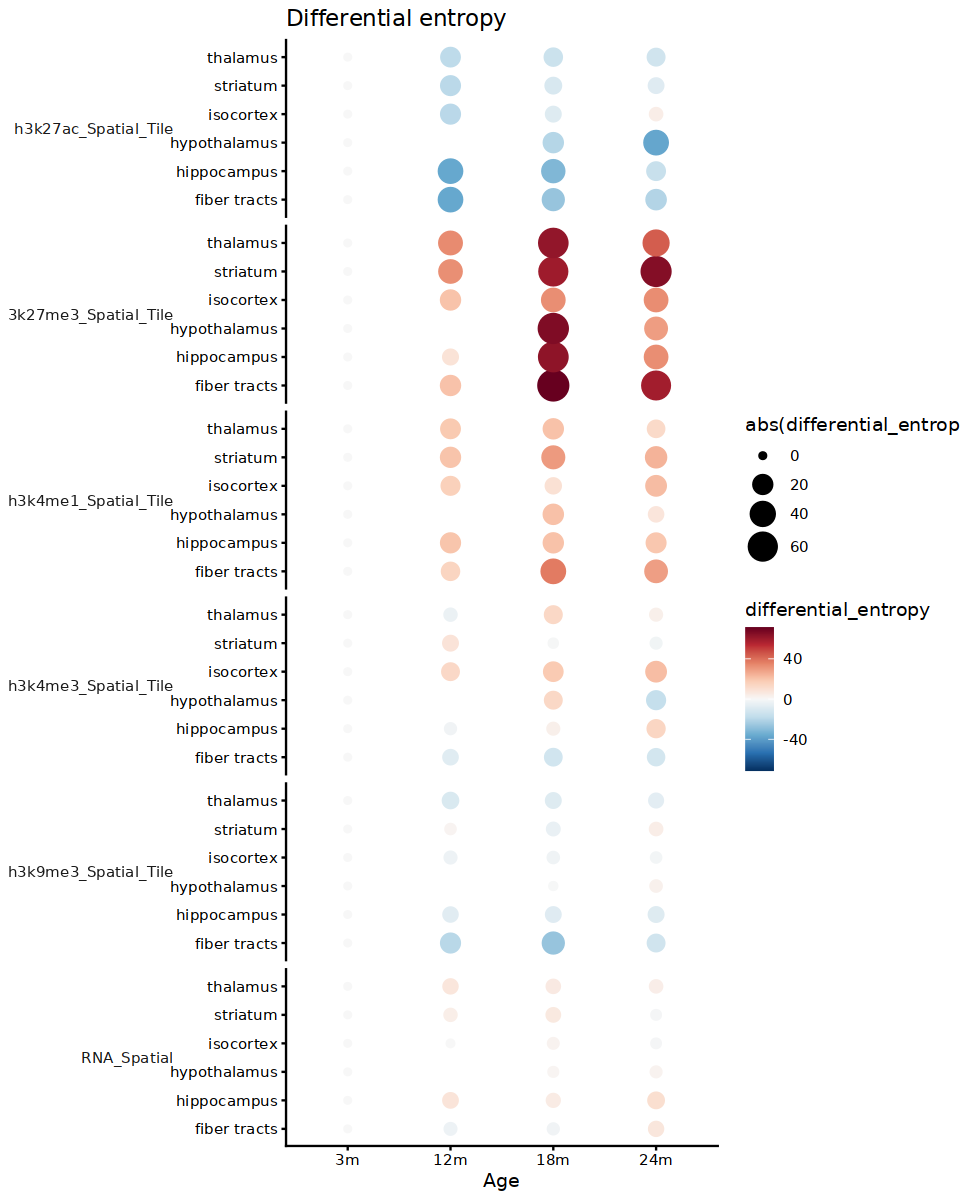

In [7]:
max_abs_diff <- max(abs(entropy_df$differential_entropy), na.rm = TRUE)
color_limits <- c(-max_abs_diff, max_abs_diff)

options(repr.plot.width=8, repr.plot.height=10)
p <- ggplot(entropy_df, aes(x = age, y = annotation, size = abs(differential_entropy), color = differential_entropy)) +
  geom_point() +
  scale_color_gradientn(colors = jdb_palette('brewer_yes'), limits = color_limits, oob = scales::squish) +
  scale_size(range = c(1.5, 8), limits = c(0, max_abs_diff)) +
  facet_grid(assay ~ ., switch = "y", scales = "fixed") +
  theme_classic() +
  theme(strip.placement = "outside",
        strip.background = element_blank(),
        strip.text.y.left = element_text(angle = 0, hjust = 1, vjust = 0.5),
        axis.title.y = element_blank()) +
  ggtitle('Differential entropy') +
  xlab('Age') +
  theme(legend.position = 'right')

print(p)